<a href="https://colab.research.google.com/github/susanab3/music-emotion-project/blob/main/Report_Multimodal_Music_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multimodal Music Emotion Recognition via Valence-Arousal with Multi-Label Mapping**



**Susana Bautista**  
**40246311**  
**COMP 432 – Final Project**  
**April 19, 2026**

## Full Code Availability

The complete implementation of this project, including all phases (data preparation, feature extraction, modeling, tuning, and evaluation), is available on GitHub.

You can access the full code here:  
[https://github.com/susanab3/music-emotion-project.git](https://github.com/susanab3/music-emotion-project.git)

Instructions on how to open and run the notebook are provided in the README file in the repository.



---



## **Abstract**



The goal of this project is recognizing emotions in music by combining both audio and lyrics. The main focus is to move beyond predicting a single emotion and instead capture the full emotional complexity of a song using a multimodal approach. The MERGE dataset is used, which provides audio, lyrics, and continuous valence–arousal (VA) labels.

First, audio and lyrics are converted into embeddings using pretrained models. Baseline models are built using each modality separately, followed by a multimodal neural network that fuses both inputs to predict valence and arousal. The model is then improved through hyperparameter tuning and evaluated on a test set. Results show that the multimodal model outperforms the audio-only and lyrics-only baselines in predicting VA values.

To make the results easier to interpret, predicted VA values are converted into multiple emotion labels (happy, sad, calm, and more), allowing each song to have more than one emotion, therefore a multi-label emotion recognition. This approach is also compared with a direct mood prediction model trained on human-annotated labels. It predicts mood labels directly from the dataset.


Overall, the results show that combining audio and lyrics improves emotion prediction compared to using only one modality, and that mapping VA values to multiple emotions provides a more realistic representation of how music expresses emotion.



---



## **Introduction**



Music can express more than one emotion at the same time. However, many systems only predict a single emotion or only use numerical values like valence and arousal. This makes it harder to fully understand how a song actually feels. Being able to detect multiple emotions is important for applications like music recommendation and analysis.

Valence and arousal (VA) are commonly used to represent emotions (Figure 1). Valence measures how positive or negative a song is, while arousal measures how energetic or calm it is. Even though this is useful, it is not always easy to interpret. On the other hand, emotion labels like happy or sad are easier to understand, but they often ignore that a song can have multiple emotions at once.

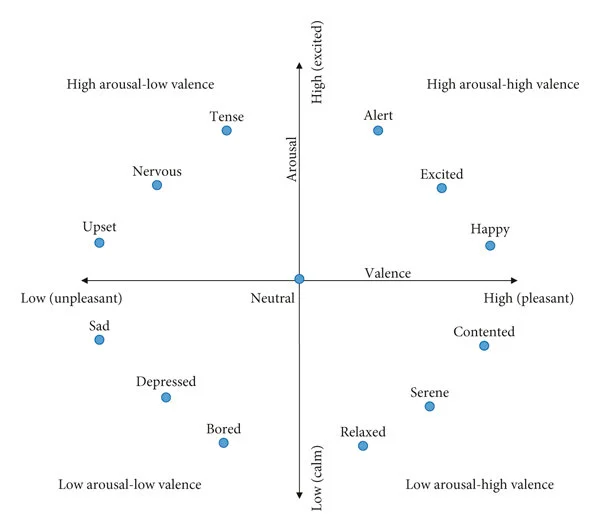

**Figure 1. Valence–Arousal Emotion Space.**  
*Emotions are mapped based on valence (positive–negative) and arousal (calm–excited); adapted from Tiwari & Falk (2019).*

The valence and arousal distributions show how emotions are spread in the dataset (Figure 2). Valence is bimodal, with peaks at low and high values, indicating mostly negative and positive emotions with fewer neutral songs. Arousal is more centered, with most values around the middle, meaning many songs have moderate energy levels. THe dataset covers a range of emotions but is slightly imbalanced, which can make prediction more challenging.

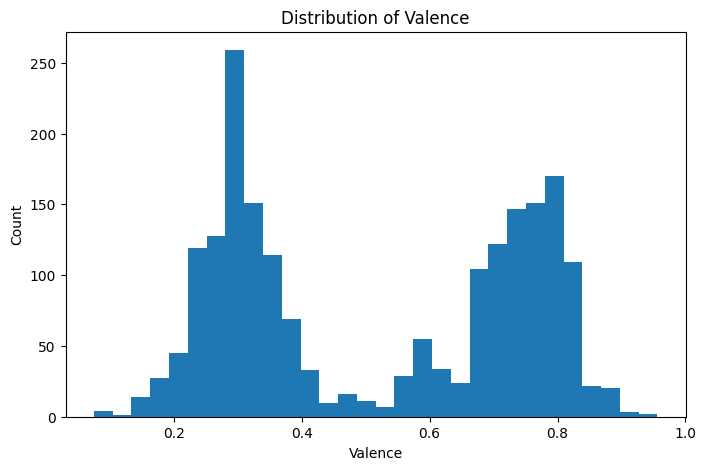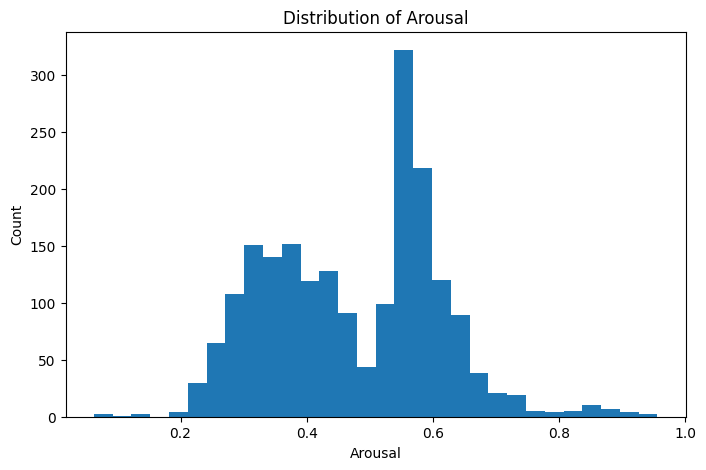

**Figure 2. Valence and Arousal Distributions**
*Valence is bimodal (mostly low and high values), while arousal is centered around the middle, indicating mostly moderate energy levels.*

Most previous work in music emotion recognition uses either audio or lyrics, not both, which limits performance because each captures different parts of emotion. Audio reflects sound and energy, while lyrics reflect meaning and context.

Recent studies have explored multimodal approaches that combine both modalities and model emotions in the valence–arousal space, showing improved performance compared to unimodal methods ([Multimodal Music Emotion Recognition via Valence-Arousal with Multi-Label Mapping](https://arxiv.org/abs/2407.06060)). However, many of these approaches still focus on predicting either continuous VA values or a single emotion label, instead of multiple emotions per song.

This project combines both using a multimodal model, which leads to better predictions. This project addresses limitations mentioned by converting valence–arousal predictions into multiple emotion labels, so each song can have several emotions at once. This makes the results more realistic and easier to understand.

In this project, audio and lyrics are first converted into embeddings using pretrained models. Then, a neural network combines both to predict valence and arousal. These values are later converted into multiple emotion labels, so each song can have more than one emotion.
A key challenge is aligning audio and lyrics and handling the imbalance in emotion distributions.

Also, an extra step is added with direct mood prediction, where the model learns to predict human-annotated mood labels directly.

These labels come from the MERGE dataset metadata, which includes mood tags assigned to each song along with weights indicating their importance.

This provides a comparison between rule-based VA mapping and a data-driven approach learned from human annotations.

The project uses the MERGE dataset, which contains around 2,000 songs with audio, lyrics, and emotion labels. Results show that combining audio and lyrics performs better than using only one of them.



---



## **Methodology**


This project follows a multimodal machine learning pipeline to predict emotions in music using both audio and lyrics. The approach is divided into several key steps: data preparation, feature extraction, modeling, and emotion prediction.

For clarity, the project is organized into multiple phases, from data preparation and feature extraction to modeling, tuning, and final evaluation (Phases 1–9).

### **1. Data Preparation**

I start by cleaning the MERGE dataset to keep only samples that contain audio, lyrics, and valence–arousal (VA) labels. The data is split into training, validation, and test sets using a 70/15/15 ratio to ensure fair evaluation and avoid data leakage.

Basic preprocessing is applied to both modalities. Audio files are converted to mono and resampled to a consistent sampling rate. Lyrics are cleaned and formatted, and long texts are split into smaller chunks. This step ensures that both inputs are consistent and ready for feature extraction.


### **2. Feature Extraction**

Instead of training models from scratch, I use pretrained models to extract embeddings:

* Audio embeddings: extracted using a pretrained MERT model
* Lyrics embeddings: extracted using Sentence-BERT

For audio, each song is divided into smaller chunks, and an embedding is created for each part. These embeddings are then averaged to get one final representation for the song. The same process is applied to the lyrics, where the text is split into chunks, embedded, and averaged into a single vector.

As a result, each song is represented by two vectors, one for audio and one for lyrics, along with its VA labels. These embeddings are used as inputs to all models in later stages.


This step is important because it allows the model to capture rich audio and textual information without requiring large training data.

### **3. Baseline Models**

To evaluate the benefit of multimodal learning, two baseline models are trained:

* Audio-only model
* Lyrics-only model

Both models use simple regression (Ridge regression) to predict valence and arousal. These baselines provide a reference point and help show whether combining both modalities actually improves performance.

### **4. Multimodal Model**

The core idea of this project is a multimodal neural network that combines audio and lyrics. I design a model with two branches, one for audio embeddings and one for lyrics embeddings. Each branch processes its input separately, and the outputs are then combined in a fusion layer.

The fused representation is used to predict valence and arousal. This architecture allows the model to learn complementary information, since audio captures sound and energy while lyrics capture meaning and context. Compared to unimodal models, this leads to improved performance.


#### **Multimodal Model Architecture**

Figure 3 shows the architecture of the multimodal neural network used to predict valence and arousal. The model takes two inputs for each song: an audio embedding and a lyrics embedding, both obtained from pretrained models.

The network is divided into two parallel branches. The audio branch processes the audio embedding, while the lyrics branch processes the lyrics embedding. Each branch consists of fully connected layers with ReLU activations and dropout. These layers transform the original embeddings into higher-level representations that capture important features from each modality.

The outputs of both branches are then combined using concatenation. This fusion step creates a single representation that contains information from both audio and lyrics. The fused vector is passed through additional fully connected layers, which further refine the combined features.

Finally, the model outputs two values: valence and arousal. These are continuous values, so the model is trained as a regression task.



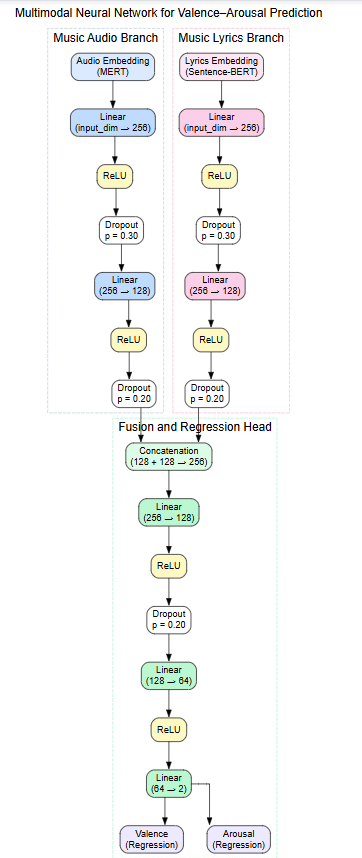

**Figure 3. Multimodal architecture used for valence–arousal prediction.**  
*Audio and lyrics embeddings are processed in separate neural network branches, fused by concatenation, and passed through fully connected layers to predict valence and arousal.*

### **5. Hyperparameter Tuning**

To improve the model, I tune several hyperparameters such as learning rate, hidden layer size, dropout, and batch size. The selection is based only on validation performance, and the test set is not used during this process.

After 80 trials, I found that the best configuration (at trial 70) uses a hidden size of 512, dropout of 0.3, learning rate of 0.001, and batch size of 32. The model achieves its best validation performance at epoch 35, with a validation loss of 0.01632.

These hyperparameters are then used to train the final model, ensuring that the evaluation remains fair.

### **6. Valence–Arousal to Emotion Mapping**

One limitation of VA prediction is that it is not always easy to interpret. To address this, I convert the predicted VA values into multi-label emotion outputs.

First, VA values are rescaled from the range [0,1] to [-1,1]. Then, regions of the VA space are mapped to emotion labels such as happy, sad, calm, and energetic. Instead of assigning a single label, multiple emotions can be assigned to each song.

This step is important because it makes the results more realistic and easier to understand.


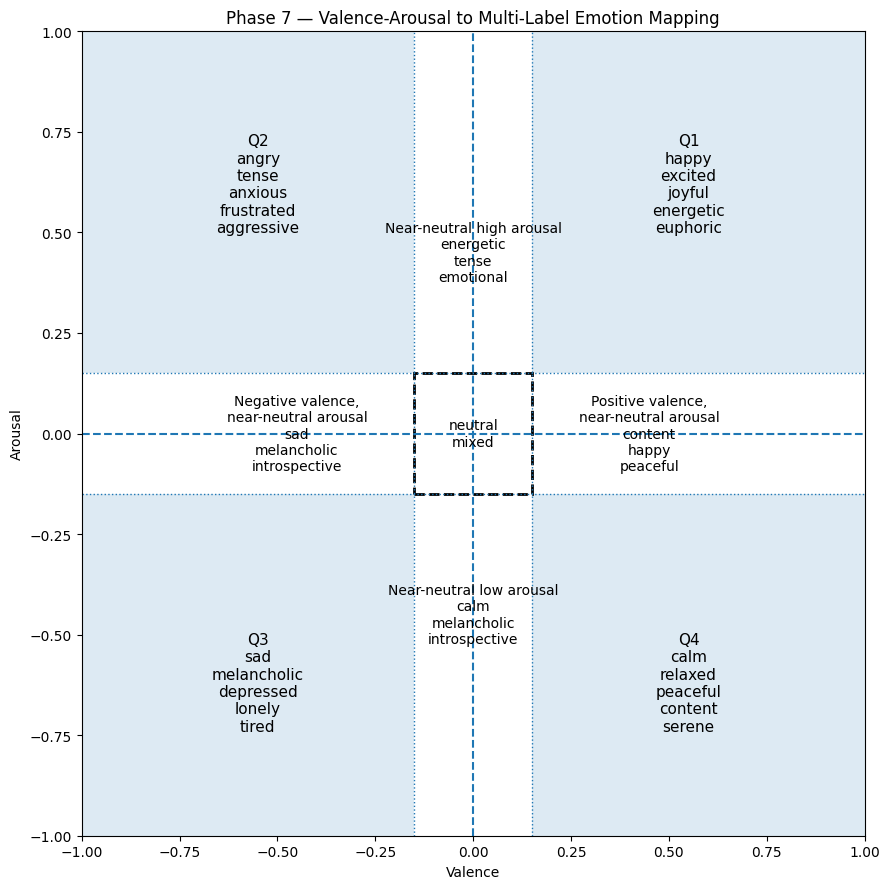

**Figure 4. VA to Emotion Mapping**  
*Mapping from valence–arousal space to multiple emotion labels.*


### **7. Direct Mood Prediction**

In addition to the rule-based mapping, I also explore a data-driven approach. For this part, I use the MERGE metadata fields **MoodsAll** and **MoodsAllWeights**, which provide mood tags for each song together with weights showing how strongly each mood is associated with that song. I then select the top 15 most frequent moods and build a **multi-label target**, so each song can have several mood labels at once.

The model uses the same multimodal idea as the VA predictor. It has one branch for **audio embeddings** and one branch for **lyrics embeddings**. Each branch passes through linear layers with ReLU activation and dropout, then both branches are concatenated and sent to a final classifier that predicts multiple moods at the same time. The model is trained with binary cross-entropy loss with logits, which is suitable for multi-label classification.

This allows me to compare two approaches: converting VA values into emotion labels with rules, or predicting mood labels directly from annotated data. This comparison is one of the original parts of the project.

### **8. Evaluation**

The models are evaluated using standard machine learning metrics.

For VA prediction, I use RMSE, MAE, and R².  
For emotion prediction, I use F1 scores, hamming loss, and exact match accuracy.  



**Summary**

The most important parts of this methodology are the use of pretrained embeddings, the multimodal neural network, and the conversion from VA values to multi-label emotions. Together, these steps improve both the accuracy and interpretability of music emotion recognition.




---




## **Experimental Setup**



This section summarizes the dataset, models, and training settings used in the experiments.

### **Dataset**

The MERGE dataset is a multimodal music dataset that combines audio clips, lyrics, and emotion annotations. It is built by merging data from multiple sources, including music metadata platforms and lyric databases. Each song is matched across these sources using shared identifiers, and only songs that have audio, lyrics, and emotion labels are kept.

The experiments use the MERGE bimodal dataset, which contains around 2,000 songs with audio, lyrics, and valence–arousal (VA) labels. After cleaning, only samples with both modalities are kept.

These values are based on human annotations or previously labeled datasets, making them a reliable representation of perceived emotion.


The dataset is split into 70% training, 15% validation, and 15% test to ensure proper evaluation and avoid data leakage.

### **Feature Representation**

Each song is represented using pretrained embeddings. Audio features are extracted using MERT (768 dimensions), and lyrics are encoded using Sentence-BERT (384 dimensions). These embeddings are used as inputs to all models.

### **Models**

Three types of models are evaluated:
- unimodal baselines using audio-only and lyrics-only inputs  
- a multimodal regression model for VA prediction  
- a multimodal classifier for direct mood prediction  

### **Training Setup**

The regression model is trained using Mean Squared Error loss and the Adam optimizer, with early stopping based on validation loss. The mood prediction model uses Binary Cross-Entropy for multi-label classification.

### **Hyperparameters**

The final multimodal model uses tuned hyperparameters: learning rate 0.001, hidden size 512, dropout 0.30, and batch size 64. Training runs for up to 80 epochs with early stopping. The best validation performance is achieved at epoch 35 with a validation loss of 0.01632.


### **Evaluation Metrics**

Performance is measured using:
- RMSE, MAE, and R² for VA prediction  
- F1 scores, hamming loss, and exact match accuracy for multi-label emotion prediction  




---



## **Experimental Results**


### **1. Valence–Arousal Prediction**


I first evaluate how well each model predicts valence and arousal as continuous values.

The comparison includes:
- lyrics-only baseline  
- audio-only baseline  
- initial multimodal model  
- final tuned multimodal model  

**Before showing final results. Let's first look at the baseline models performance.**





The baseline results show that each modality captures different aspects of emotion (Figure 5).

For **arousal**, the audio-only model has lower RMSE than the lyrics-only model, so it performs better. This makes sense because arousal is related to energy, which is easier to capture from audio.

For **valence**, the lyrics-only model has lower RMSE than the audio-only model. This is because lyrics contain words and meaning that better reflect whether a song is positive or negative.

**Figure 5. Baseline RMSE Comparison**  
*Comparison of lyrics-only and audio-only models for valence and arousal prediction.*


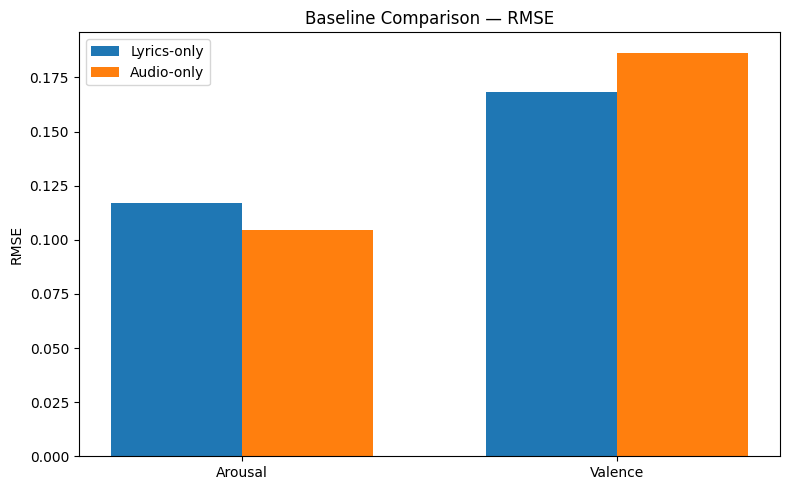

**Multimodal Model Performance (Before Tuning)**

I then train a multimodal neural network that combines audio and lyrics.




Table 1 shows the performance of all models for predicting valence and arousal using regression metrics (MSE, RMSE, MAE, and R²).




As discussed in the baseline results, each modality captures different aspects of emotion. Lyrics perform better for **valence prediction** (RMSE = 0.168, R² = 0.45), while audio performs better for **arousal prediction** (RMSE = 0.104, R² = 0.42).

The **initial multimodal model** improves over both baselines, especially for valence. It achieves the lowest RMSE (0.165) and highest R² (0.49), showing that combining audio and lyrics helps capture complementary emotional information.

For arousal, the multimodal model (RMSE = 0.113, R² = 0.34) does not outperform the audio-only baseline, but remains competitive.

**Table 1. VA Prediction Results**

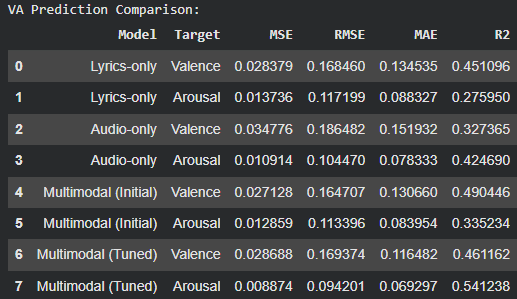

The initial model improves performance compared to both baselines, especially for valence prediction. This confirms that combining modalities helps capture more complete emotional information.

However, performance is still limited by the choice of hyperparameters.

**Effect of Hyperparameter Tuning**


To improve performance, I tune the model using the validation set.

The **tuned multimodal model** shows clear improvements, especially for arousal prediction. It achieves the best overall performance with RMSE = 0.094 and R² = 0.54, outperforming all previous models.

This indicates better generalization and more accurate prediction of energy-related features.

For valence, performance slightly decreases compared to the initial multimodal model (RMSE = 0.169, R² = 0.46). This suggests a trade-off, where tuning improves arousal more significantly while slightly impacting valence.

The Table 1 and Figure 6 are consistent and show that the tuned multimodal model achieves the best performance for arousal, while the initial multimodal model performs best for valence.


**Figure 6. RMSE Comparison**


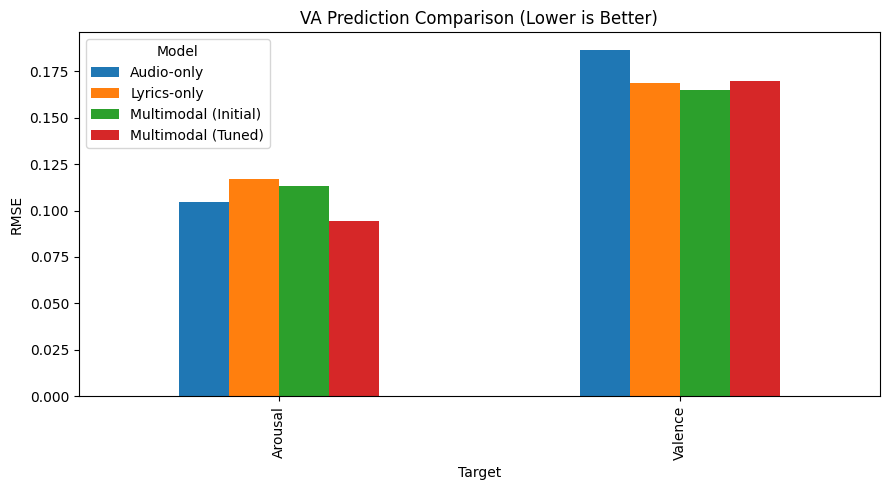

To summarize, hyperparameter tuning improves the model’s ability to generalize, particularly for arousal, and plays an important role in optimizing multimodal performance.


### **2. Emotion Prediction**

Next, I evaluate emotion prediction using two approaches:
- VA → emotion mapping  
- direct mood prediction  



The first approach maps predicted valence–arousal (VA) values to emotion labels using predefined thresholds. The second approach uses a multimodal model to directly predict emotion labels from audio and lyrics using human-annotated mood data.






Figure 7 shows how each song’s valence and arousal values are placed in a 2D space and grouped into regions that represent different emotions. Depending on where a point falls (quadrant or near the center), it is assigned one or more emotion labels like happy, sad, calm, or angry.

**Figure 7. Valence–Arousal to Emotion Mapping**  
*Quadrant-based mapping used to convert VA predictions into multiple emotion labels.*

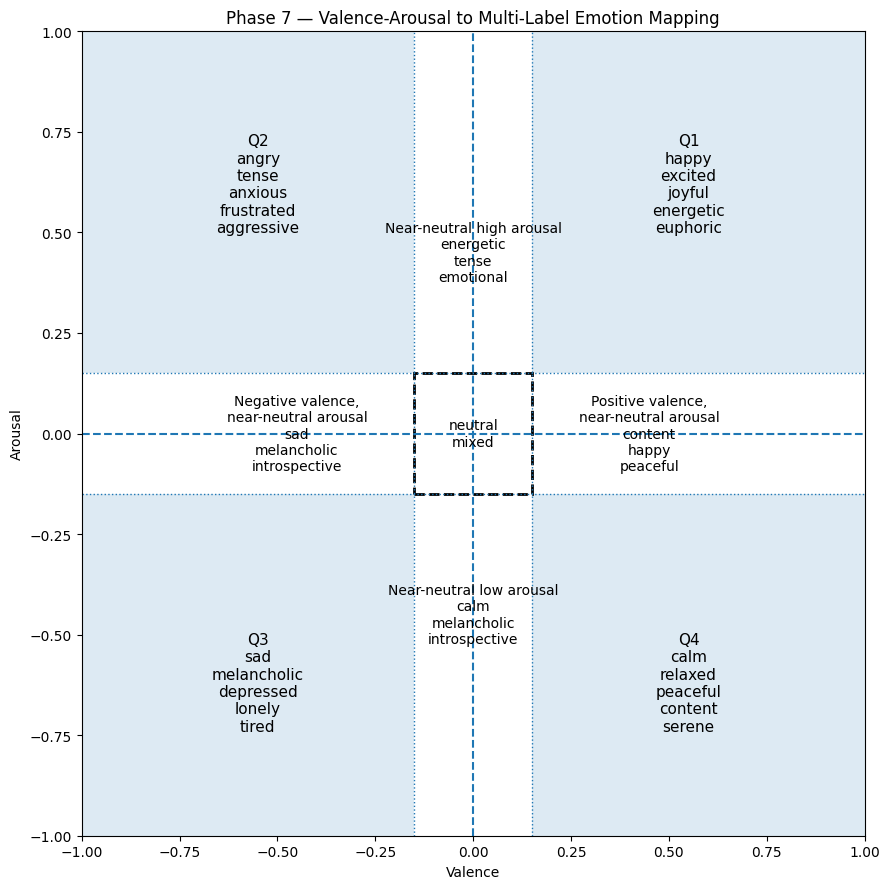

Table 2 and Figure 8 show the results using multi-label classification metrics, including F1 scores, exact match accuracy, and hamming loss.


**Table 2. Emotion Prediction Results**

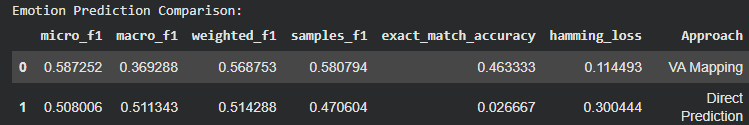

**Figure 8. F1 Score Comparison**

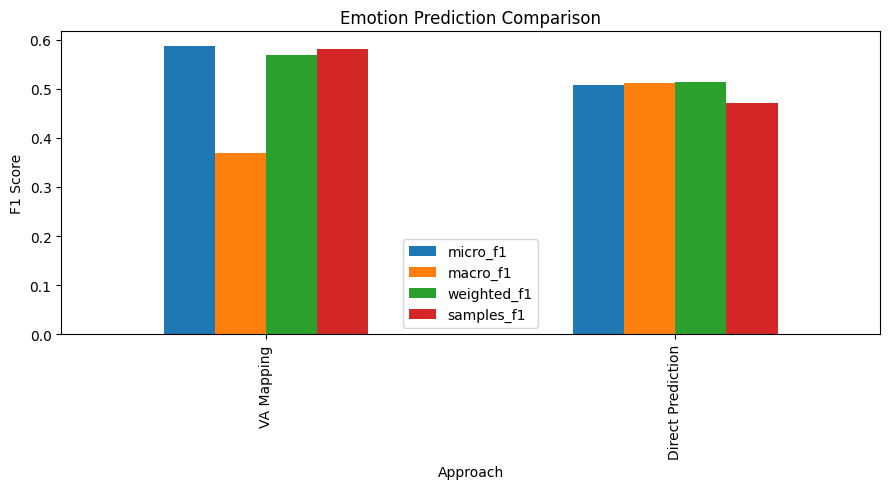

The results show clear differences between the two approaches.

The **VA mapping approach** achieves higher performance on most metrics. It has a higher micro F1 score (0.587 vs 0.508), weighted F1 (0.569 vs 0.514), and samples F1 (0.581 vs 0.471), showing better overall performance across the predicted emotion labels.

The higher **micro F1** means the mapping approach makes more correct predictions overall. The higher **weighted F1** shows that it performs well even when some emotions appear more often than others.

The **samples F1 score** is also higher, which means that the set of predicted emotions for each song is closer to the true set. This indicates better performance in the multi-label setting.

In addition, the mapping approach has a much higher **exact match accuracy** (0.463 vs 0.027), meaning it is much more likely to correctly predict all emotions for a song. It also has a lower **hamming loss** (0.114 vs 0.300), which means it makes fewer mistakes across all labels.

Taken together, these results show that the VA mapping approach produces more accurate and consistent multi-label predictions. This is likely because it uses the structure of the valence–arousal space to guide how emotions are assigned.

However, the **direct mood prediction approach** achieves a higher macro F1 score (0.511 vs 0.369). This suggests that it performs better across less frequent emotion classes, likely because it learns directly from labeled data rather than relying on fixed thresholds.

In general, the VA mapping approach performs better in terms of overall accuracy and consistency, while direct prediction shows some advantages in handling class imbalance. These results highlight a trade-off between a simple, interpretable rule-based method and a more flexible, data-driven model.

This comparison shows that mapping VA predictions to emotions is an effective and reliable approach, while direct mood prediction may require more data or further tuning to reach similar performance.



---



## **Conclusions**

In this project, I explored multimodal music emotion recognition by combining audio and lyrics to predict valence–arousal (VA) and map them to multi-label emotions.

I found that multimodal learning improves performance over unimodal models. Lyrics are more effective for valence, while audio is better for arousal, and combining both leads to the best overall results. Hyperparameter tuning improves performance, especially for arousal, but introduces a small trade-off for valence.

For emotion prediction, I observed that the VA mapping approach produces more accurate and consistent results, while direct mood prediction performs better on less frequent classes.

One limitation I encountered is that the dataset is relatively small and slightly imbalanced, which affects generalization. The VA-to-emotion mapping is also rule-based and may not capture all emotional nuances. Due to time constraints, I did not explore more advanced fusion methods or deeper hyperparameter tuning.

For future work, I would consider using larger or more balanced datasets, replacing the rule-based mapping with a model that learns how to assign emotions from data, and testing more advanced multimodal architectures such as cross-modal attention models (transformers that learn interactions between audio and lyrics) and late or hybrid fusion networks.

I can conclude that combining audio and lyrics with a valence–arousal-based mapping is an effective approach for multi-label emotion recognition.

## **References** ##
Tiwari, Abhishek & Falk, Tiago. (2019). Fusion of Motif- and Spectrum-Related Features for Improved EEG-Based Emotion Recognition. Computational Intelligence and Neuroscience. 2019. 1-14. 10.1155/2019/3076324.

Louro, P. L., Redinho, H., Ribeiro, T. F. R., Santos, R., Malheiro, R., Panda, R., & Paiva, R. P. (2026). MERGE: A Bimodal Audio-Lyrics Dataset For Static Music Emotion Recognition. IEEE Transactions on Affective Computing.

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split